# ANN for Predictive Maintenance

Binary classification: **Machine Failure** detection using Artificial Neural Network.

**Metrics**: Precision, Recall, F1-Score, mAP (Average Precision — best for imbalanced datasets)

**Architecture**: 128 → 64 → 32 → 1 (sigmoid)

**Dataset**: AI4I 2020 Predictive Maintenance — 8000 train / 2000 test samples

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, classification_report,
    confusion_matrix, precision_recall_curve, roc_curve, auc
)

print("Libraries loaded successfully")


Libraries loaded successfully


In [2]:
X_train = pd.read_csv("X_train_scaled.csv")
X_test  = pd.read_csv("X_test_scaled.csv")
y_train = pd.read_csv("y_train.csv").values.ravel()
y_test  = pd.read_csv("y_test.csv").values.ravel()

print("X_train shape:", X_train.shape)
print("X_test  shape:", X_test.shape)
print("y_train distribution:", dict(zip(*np.unique(y_train, return_counts=True))))
print("y_test  distribution:", dict(zip(*np.unique(y_test,  return_counts=True))))
print("\nFeature columns:", list(X_train.columns))
X_train.head()


X_train shape: (8000, 8)
X_test  shape: (2000, 8)
y_train distribution: {np.int64(0): np.int64(7729), np.int64(1): np.int64(271)}
y_test  distribution: {np.int64(0): np.int64(1932), np.int64(1): np.int64(68)}

Feature columns: ['Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear', 'Temp difference', 'Type_L', 'Type_M']


,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Temp difference,Type_L,Type_M
0,0.998914,0.604282,-0.460607,0.718305,-0.843997,-1.100842,False,True
1,-1.505194,-1.153260,-0.775574,0.638456,0.382263,1.299658,False,True
2,0.498092,1.077466,-1.007654,0.558607,0.460870,0.599512,False,True
3,-0.553633,-0.139294,-0.709265,1.626586,-0.372359,0.899575,True,False
4,-1.455112,-1.018064,1.070019,-1.128202,-0.906882,1.399679,True,False


## Exploratory Data Analysis

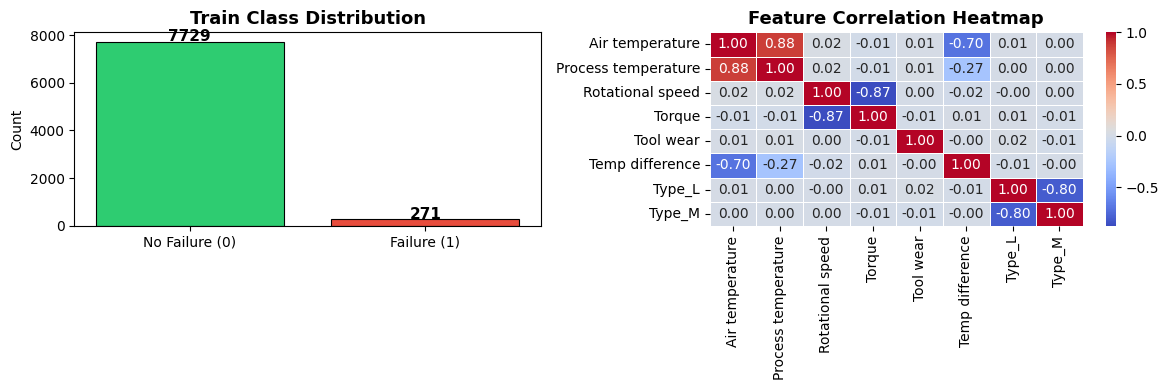

Class imbalance ratio (train): 28.5 : 1


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution
labels = ["No Failure (0)", "Failure (1)"]
counts = [int(sum(y_train==0)), int(sum(y_train==1))]
colors = ["#2ecc71", "#e74c3c"]
bars = axes[0].bar(labels, counts, color=colors, edgecolor="black", linewidth=0.8)
axes[0].set_title("Train Class Distribution", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Count")
for bar, v in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 30, str(v),
                 ha="center", fontweight="bold", fontsize=11)

# Feature correlation heatmap
corr = X_train.astype(float).corr()
sns.heatmap(corr, ax=axes[1], cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
axes[1].set_title("Feature Correlation Heatmap", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Class imbalance ratio (train): {counts[0]/counts[1]:.1f} : 1")


## Model: Multilayer Perceptron (ANN)

Architecture: **Input(8) → Dense(128, ReLU) → Dense(64, ReLU) → Dense(32, ReLU) → Output(1, sigmoid)**

Early stopping is used to prevent overfitting.

In [4]:
ann = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    max_iter=300,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    learning_rate_init=0.001
)

ann.fit(X_train, y_train)
print("Training complete!")
print(f"Iterations run : {ann.n_iter_}")
print(f"Final train loss: {ann.loss_:.6f}")


Training complete!
Iterations run : 53
Final train loss: 0.033062


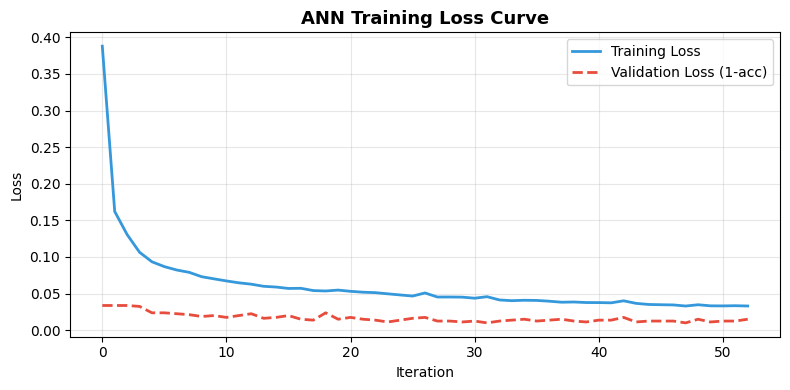

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(ann.loss_curve_, color="#3498db", lw=2, label="Training Loss")
if ann.validation_scores_ is not None:
    val_loss = [1 - s for s in ann.validation_scores_]
    plt.plot(val_loss, color="#e74c3c", lw=2, linestyle="--", label="Validation Loss (1-acc)")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("ANN Training Loss Curve", fontsize=13, fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()


## Threshold Tuning

With a ~28:1 class imbalance, the default 0.5 threshold may not be optimal. We sweep thresholds and pick the one maximising F1 on the minority class.

In [6]:
y_pred = ann.predict(X_test)
y_prob = ann.predict_proba(X_test)[:, 1]

# Find best threshold by F1
thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores  = [f1_score(y_test, (y_prob >= t).astype(int), zero_division=0) for t in thresholds]
best_thresh = thresholds[int(np.argmax(f1_scores))]
y_pred_best = (y_prob >= best_thresh).astype(int)

f1_default = f1_score(y_test, y_pred, zero_division=0)
f1_best    = float(max(f1_scores))
print(f"Default threshold (0.50) -> F1 = {f1_default:.4f}")
print(f"Best    threshold ({best_thresh:.2f}) -> F1 = {f1_best:.4f}")


Default threshold (0.50) -> F1 = 0.7559
Best    threshold (0.55) -> F1 = 0.7680


## Evaluation Metrics

In [7]:
precision = precision_score(y_test, y_pred_best, zero_division=0)
recall    = recall_score(y_test, y_pred_best, zero_division=0)
f1        = f1_score(y_test, y_pred_best, zero_division=0)
map_score = average_precision_score(y_test, y_prob)

print("=" * 52)
print("        ANN CLASSIFICATION METRICS")
print("=" * 52)
print(f"  Precision (best threshold) : {precision:.4f}")
print(f"  Recall                     : {recall:.4f}")
print(f"  F1-Score                   : {f1:.4f}")
print(f"  mAP (Average Precision)    : {map_score:.4f}")
print("=" * 52)
print()
print("Full Classification Report:")
print(classification_report(y_test, y_pred_best,
      target_names=["No Failure", "Failure"], zero_division=0))


        ANN CLASSIFICATION METRICS
  Precision (best threshold) : 0.8421
  Recall                     : 0.7059
  F1-Score                   : 0.7680
  mAP (Average Precision)    : 0.8205

Full Classification Report:
              precision    recall  f1-score   support

  No Failure       0.99      1.00      0.99      1932
     Failure       0.84      0.71      0.77        68

    accuracy                           0.99      2000
   macro avg       0.92      0.85      0.88      2000
weighted avg       0.98      0.99      0.98      2000



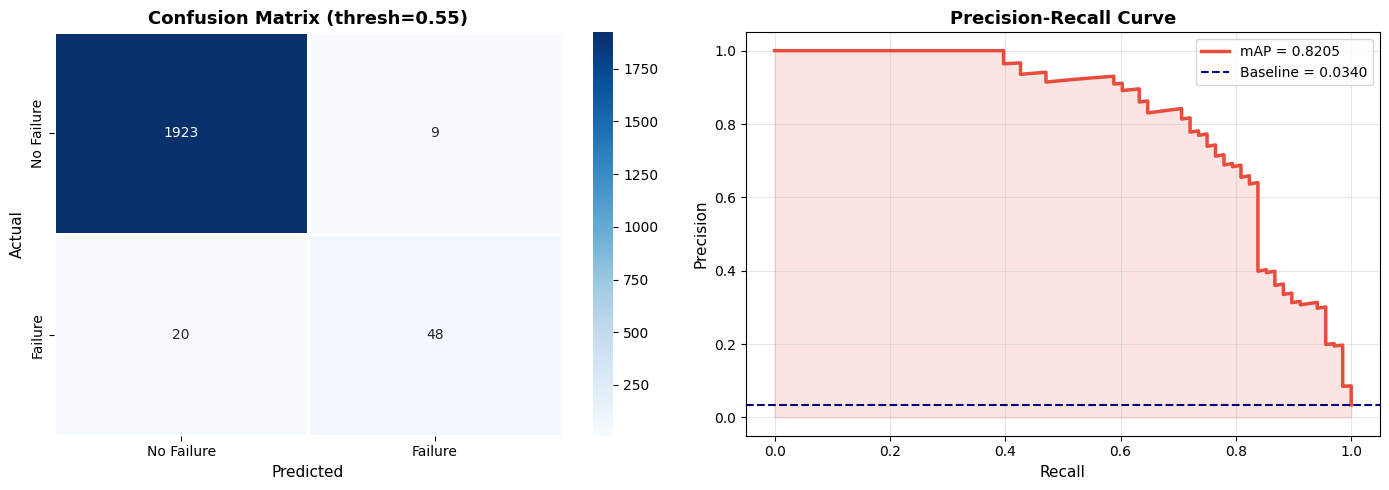

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["No Failure", "Failure"],
            yticklabels=["No Failure", "Failure"],
            linewidths=1, linecolor="white")
axes[0].set_title(f"Confusion Matrix (thresh={best_thresh:.2f})", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Actual", fontsize=11)
axes[0].set_xlabel("Predicted", fontsize=11)

# Precision-Recall Curve
prec_c, rec_c, _ = precision_recall_curve(y_test, y_prob)
axes[1].fill_between(rec_c, prec_c, alpha=0.15, color="#e74c3c")
axes[1].plot(rec_c, prec_c, color="#e74c3c", lw=2.5, label=f"mAP = {map_score:.4f}")
baseline = float(sum(y_test)) / len(y_test)
axes[1].axhline(baseline, color="navy", linestyle="--", lw=1.5, label=f"Baseline = {baseline:.4f}")
axes[1].set_xlabel("Recall", fontsize=11)
axes[1].set_ylabel("Precision", fontsize=11)
axes[1].set_title("Precision-Recall Curve", fontsize=13, fontweight="bold")
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("confusion_pr_curve.png", dpi=150, bbox_inches="tight")
plt.show()


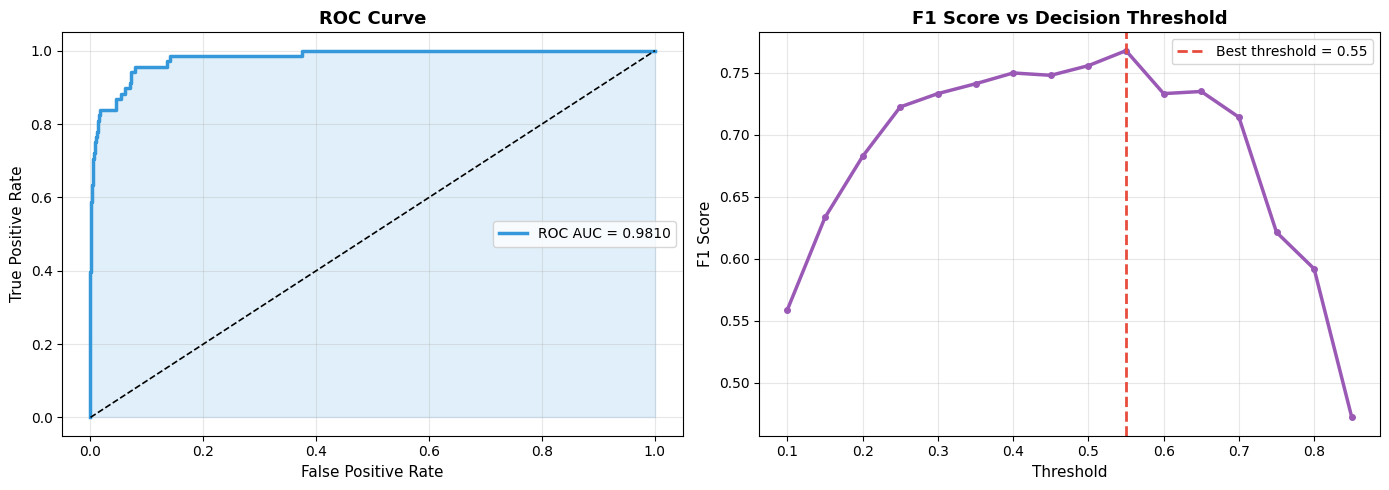

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
axes[0].fill_between(fpr, tpr, alpha=0.15, color="#3498db")
axes[0].plot(fpr, tpr, color="#3498db", lw=2.5, label=f"ROC AUC = {roc_auc:.4f}")
axes[0].plot([0,1],[0,1], "k--", lw=1.2)
axes[0].set_xlabel("False Positive Rate", fontsize=11)
axes[0].set_ylabel("True Positive Rate", fontsize=11)
axes[0].set_title("ROC Curve", fontsize=13, fontweight="bold")
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# F1 vs Threshold
axes[1].plot(thresholds, f1_scores, color="#9b59b6", lw=2.5, marker="o", markersize=4)
axes[1].axvline(best_thresh, color="#e74c3c", linestyle="--", lw=2,
                label=f"Best threshold = {best_thresh:.2f}")
axes[1].set_xlabel("Threshold", fontsize=11)
axes[1].set_ylabel("F1 Score", fontsize=11)
axes[1].set_title("F1 Score vs Decision Threshold", fontsize=13, fontweight="bold")
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("roc_threshold.png", dpi=150, bbox_inches="tight")
plt.show()


## Summary

| Metric | Description |
|--------|-------------|
| **Precision** | Of all predicted failures, how many were actual failures |
| **Recall** | Of all actual failures, how many did the model catch |
| **F1-Score** | Harmonic mean of Precision and Recall |
| **mAP** | Area under Precision-Recall curve — best metric for imbalanced data |

> **Note**: mAP is the primary metric here due to the severe class imbalance (~28:1 ratio).

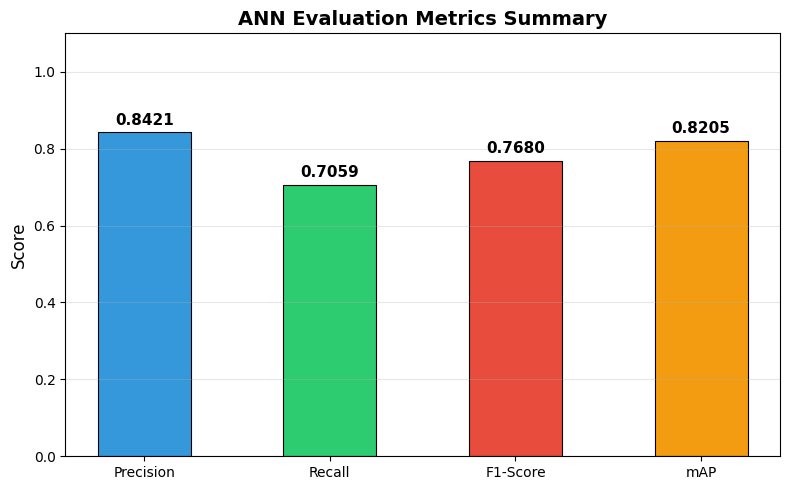


All plots saved as PNG files.


In [10]:
metrics_dict = {
    "Precision": float(precision),
    "Recall":    float(recall),
    "F1-Score":  float(f1),
    "mAP":       float(map_score)
}

fig, ax = plt.subplots(figsize=(8, 5))
palette = ["#3498db", "#2ecc71", "#e74c3c", "#f39c12"]
bars = ax.bar(metrics_dict.keys(), metrics_dict.values(),
              color=palette, edgecolor="black", linewidth=0.8, width=0.5)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("ANN Evaluation Metrics Summary", fontsize=14, fontweight="bold")
for bar, (k, v) in zip(bars, metrics_dict.items()):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.02, f"{v:.4f}",
            ha="center", fontsize=11, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("metrics_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nAll plots saved as PNG files.")


## Summary

| Metric | Description |
|--------|-------------|
| **Precision** | Of all predicted failures, how many were actual failures |
| **Recall** | Of all actual failures, how many did the model catch |
| **F1-Score** | Harmonic mean of Precision and Recall |
| **mAP** | Area under Precision-Recall curve — best metric for imbalanced data |

> **Note**: mAP is the primary metric here due to the severe class imbalance (~28:1 ratio).